# Name: Adan Delgado
# Date: May 4, 2026
# Assignment: CSCI 460 – Comprehensive Final Project
# Dataset: Gas Sensor Array Drift Dataset (UCI Repository, ID: 224)


## Section 1: Setup & Imports

In [1]:
!pip install lazypredict xgboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 2.2 MB/s eta 0:00:00


In [2]:
import os
import warnings
import numpy as np
import pandas as pd

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# LazyPredict
from lazypredict.Supervised import LazyClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Section 2: Load the Dataset

In [3]:
# The dataset is split across 10 batch .dat files.
# Each line starts with a class label followed by index:value feature pairs.
# We parse all 10 batches and combine them into one DataFrame.

dfs = []
for i in range(1, 11):
    rows = []
    with open(f'Dataset/batch{i}.dat', 'r') as f:
        for line in f:
            parts = line.strip().split()
            if not parts or not parts[0].isdigit():
                continue
            label = int(parts[0])
            features = [float(v.split(':')[1]) for v in parts[1:]]
            rows.append([label] + features)
    dfs.append(pd.DataFrame(rows))

df_all = pd.concat(dfs, ignore_index=True)
y = df_all.iloc[:, 0].astype(int)
X = df_all.iloc[:, 1:]
X.columns = [f'feature_{i}' for i in range(X.shape[1])]

print('Feature matrix shape:', X.shape)
print('Target vector shape: ', y.shape)
print('Classes:', sorted(y.unique()))

Feature matrix shape: (13910, 128)
Target vector shape:  (13910,)
Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [4]:
# Encode the integer class labels (1-6) into 0-indexed labels for sklearn
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print('Gas classes (original):', le.classes_)
print('Gas classes (encoded): ', list(range(len(le.classes_))))

Gas classes (original): [1 2 3 4 5 6]
Gas classes (encoded):  [0, 1, 2, 3, 4, 5]


## Section 3: Exploratory Data Analysis (EDA)

In [5]:
# Basic summary — shape, missing values, and descriptive stats
print('=== Shape ===')
print(f'{X.shape[0]} samples, {X.shape[1]} features')
print()
print('=== Missing Values ===')
print(X.isnull().sum().sum(), 'total missing values')
print()
print('=== Descriptive Statistics (first 5 features) ===')
X.describe().iloc[:, :5]

=== Shape ===
13910 samples, 128 features

=== Missing Values ===
0 total missing values

=== Descriptive Statistics (first 5 features) ===


,feature_0,feature_1,feature_2,feature_3,feature_4
count,13910.000000,13910.000000,13910.000000,13910.000000,13910.000000
mean,50435.066174,6.638156,12.936688,18.743953,26.890695
std,69844.785952,13.486391,17.610061,24.899450,38.107685
min,-16757.598600,0.088287,0.000100,0.000100,0.000100
25%,6694.725950,2.284843,1.633350,2.386836,4.967988
50%,19364.439350,3.871227,4.977123,7.250892,11.680725
75%,63104.837125,8.400619,17.189166,26.411109,34.843226
max,670687.347700,1339.879283,167.079751,226.619457,993.605306


/tmp/ipykernel_4516/905151422.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


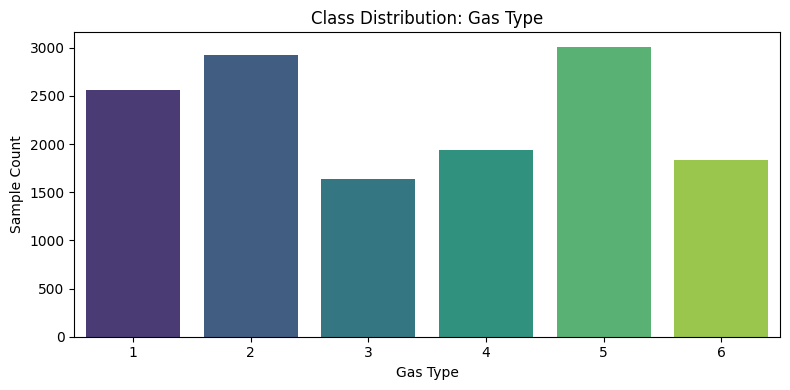

0
1    2565
2    2926
3    1641
4    1936
5    3009
6    1833
Name: count, dtype: int64


In [6]:
# Class distribution — checking if the dataset is balanced
class_counts = pd.Series(y).value_counts().sort_index()

plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Class Distribution: Gas Type')
plt.xlabel('Gas Type')
plt.ylabel('Sample Count')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print(class_counts)

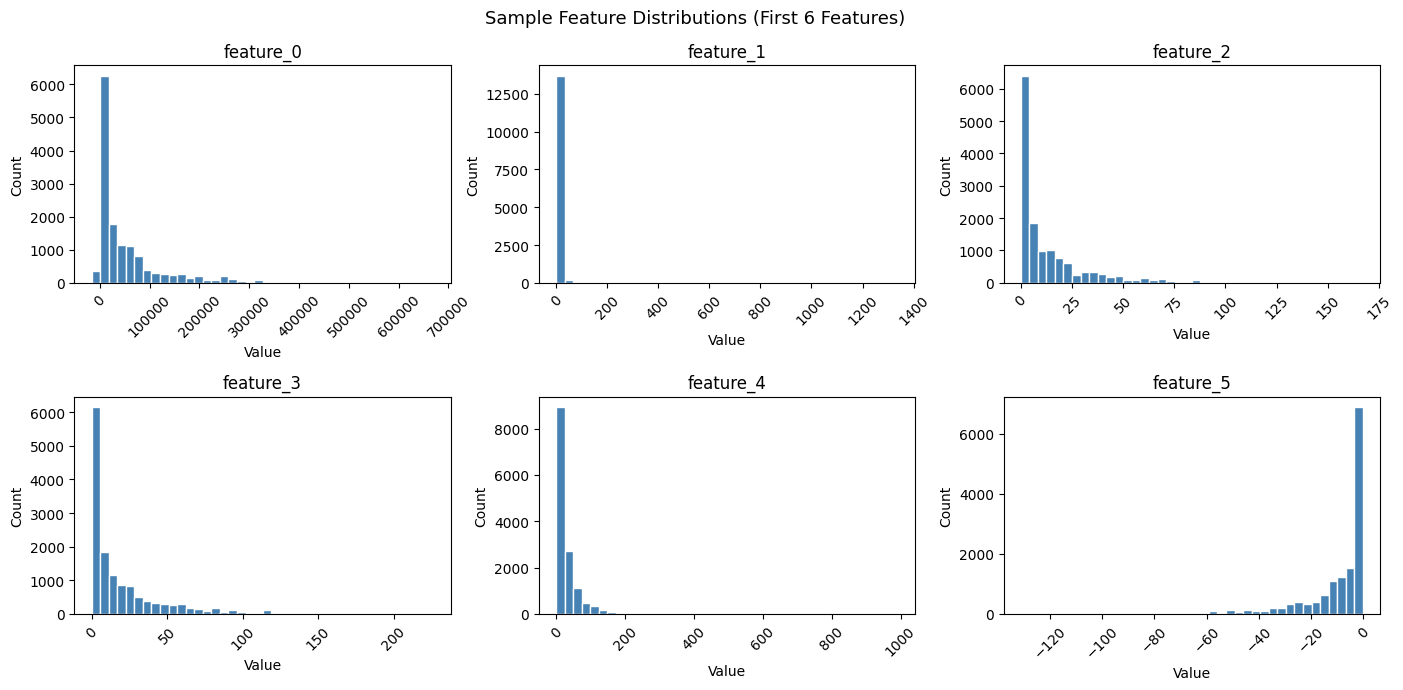

In [7]:
# Distribution of the first 6 features to get a sense of the data spread
sample_features = X.columns[:6]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), sample_features):
    ax.hist(X[col], bins=40, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Sample Feature Distributions (First 6 Features)', fontsize=13)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

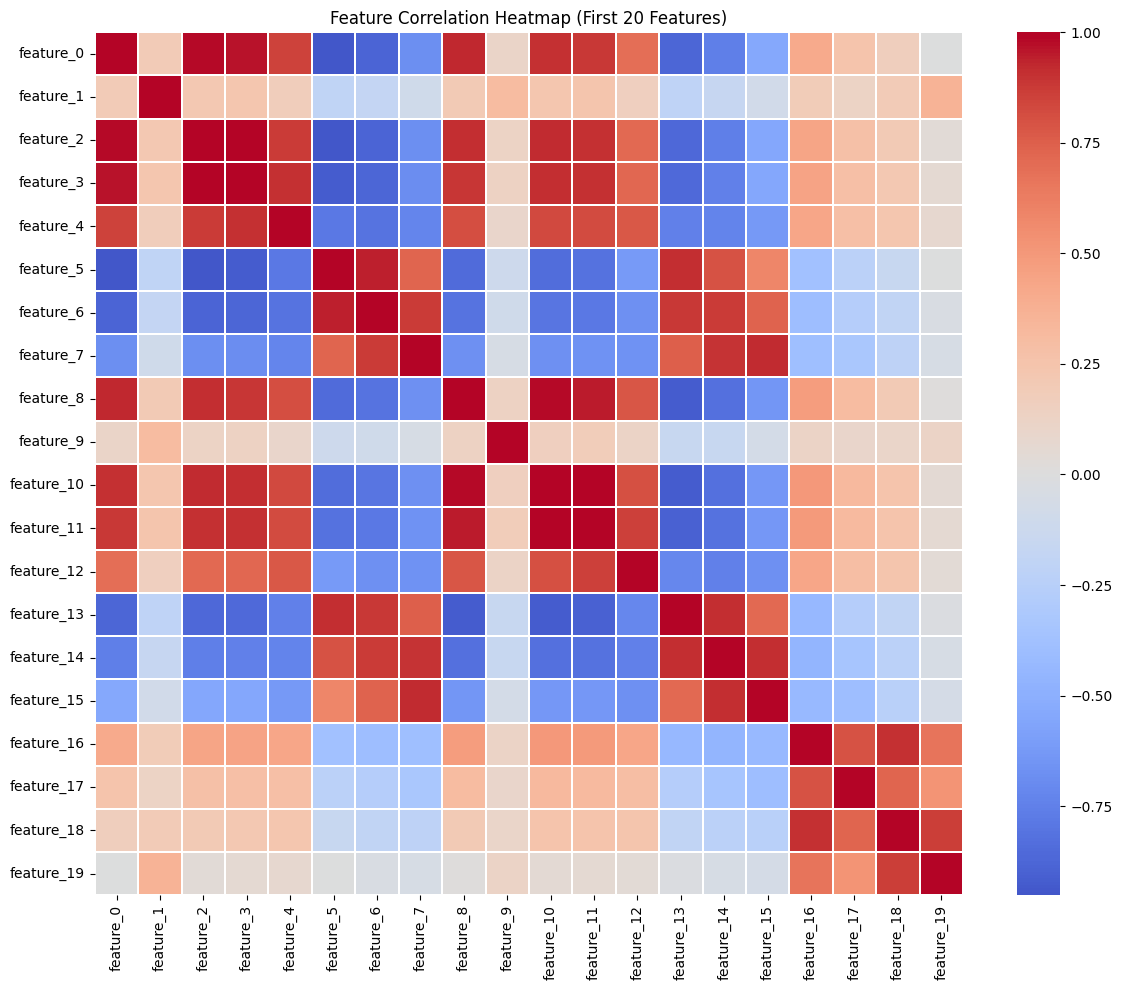

In [8]:
# Correlation heatmap — with 128 features we just look at the first 20
corr = X.iloc[:, :20].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3,
            xticklabels=True, yticklabels=True)
plt.title('Feature Correlation Heatmap (First 20 Features)')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

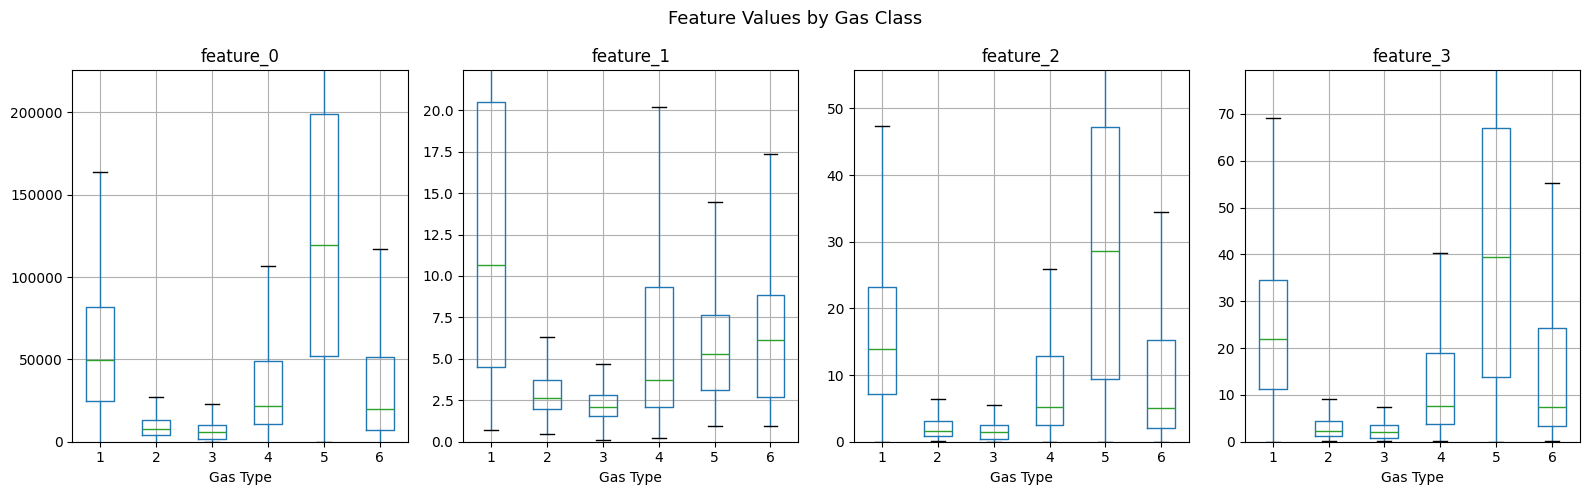

In [9]:
# Box plots to see how feature values differ across gas classes
df_eda = X.copy()
df_eda['gas_type'] = y.values

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, X.columns[:4]):
    df_eda.boxplot(column=col, by='gas_type', ax=ax, showfliers=False)
    ax.set_title(col)
    ax.set_xlabel('Gas Type')
    cap = df_eda[col].quantile(0.95)
    ax.set_ylim(0, cap * 1.1)
plt.suptitle('Feature Values by Gas Class', fontsize=13)
plt.tight_layout()
plt.savefig('boxplots_by_class.png', dpi=150)
plt.show()

Total outlier values detected: 80397
Features with most outliers (top 5):
feature_15    1862
feature_7     1767
feature_0     1418
feature_71    1380
feature_79    1355
dtype: int64


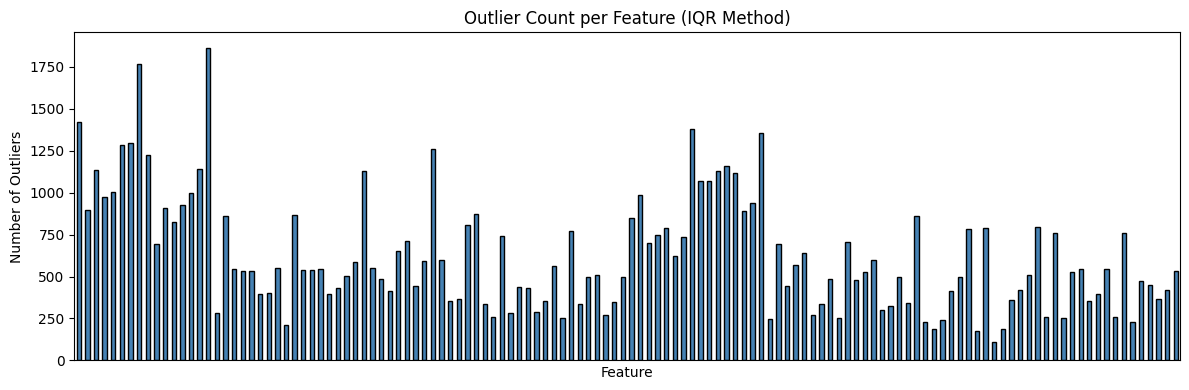

In [10]:
# Outlier detection using IQR method across all features
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR)))
outlier_counts = outlier_mask.sum()

print(f'Total outlier values detected: {outlier_mask.sum().sum()}')
print(f'Features with most outliers (top 5):')
print(outlier_counts.sort_values(ascending=False).head())

# Visualize outlier counts per feature
plt.figure(figsize=(12, 4))
outlier_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Outlier Count per Feature (IQR Method)')
plt.xlabel('Feature')
plt.ylabel('Number of Outliers')
plt.xticks([])
plt.tight_layout()
plt.savefig('outliers.png', dpi=150)
plt.show()

## Section 4: Data Preprocessing

In [11]:
# 80/20 train-test split, stratified to keep class proportions consistent
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print(f'Training set:  {X_train.shape[0]} samples')
print(f'Test set:      {X_test.shape[0]} samples')

Training set:  11128 samples
Test set:      2782 samples


In [12]:
# Scale features using StandardScaler
# Important: fit only on training data to avoid leaking test info
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete.')
print(f'Train mean (should be ~0): {X_train_scaled.mean():.4f}')
print(f'Train std  (should be ~1): {X_train_scaled.std():.4f}')

Scaling complete.
Train mean (should be ~0): 0.0000
Train std  (should be ~1): 1.0000


Original features:        128
PCA components (95% var): 12
Variance explained:       0.9505


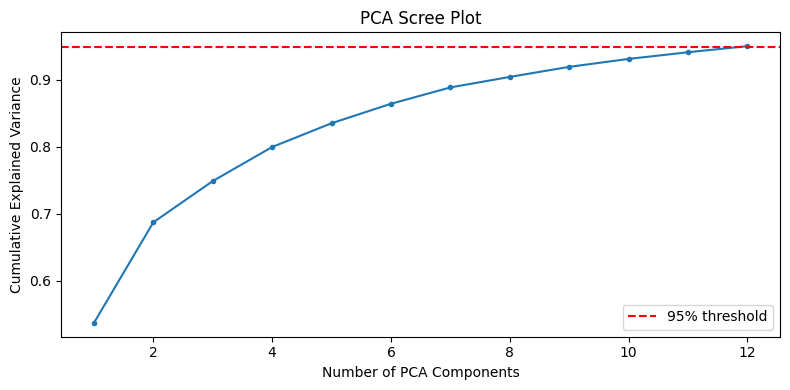

In [13]:
# PCA for dimensionality reduction
# 128 features is a lot — PCA helps reduce redundancy and speeds up training.
# Setting n_components=0.95 keeps enough components to explain 95% of the variance.

pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f'Original features:        {X_train_scaled.shape[1]}')
print(f'PCA components (95% var): {pca.n_components_}')
print(f'Variance explained:       {pca.explained_variance_ratio_.sum():.4f}')

# Scree plot
cumvar = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', markersize=3)
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot')
plt.legend()
plt.tight_layout()
plt.savefig('pca_scree.png', dpi=150)
plt.show()

## Section 5: LazyPredict Model Survey

In [14]:
# Run LazyPredict to get a quick benchmark of many classifiers
# This helps inform which models are worth tuning in Section 6
warnings.filterwarnings('ignore')

clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train_pca, X_test_pca, y_train, y_test)
print(models)

                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
ExtraTreesClassifier           0.993889           0.993425  0.999511   
LGBMClassifier                 0.992092           0.991421  0.999499   
RandomForestClassifier         0.991014           0.989508  0.999597   
KNeighborsClassifier           0.990295           0.989198  0.998038   
XGBClassifier                  0.989216           0.988289  0.999477   
LabelPropagation               0.988857           0.987369       NaN   
LabelSpreading                 0.987779           0.986030       NaN   
BaggingClassifier              0.985622           0.984309  0.997897   
SVC                            0.974838           0.970243       NaN   
DecisionTreeClassifier         0.962976           0.960357  0.977827   
ExtraTreeClassifier            0.962257           0.958030  0.977473   
LogisticRegression             0.911215           0.902112  0.98

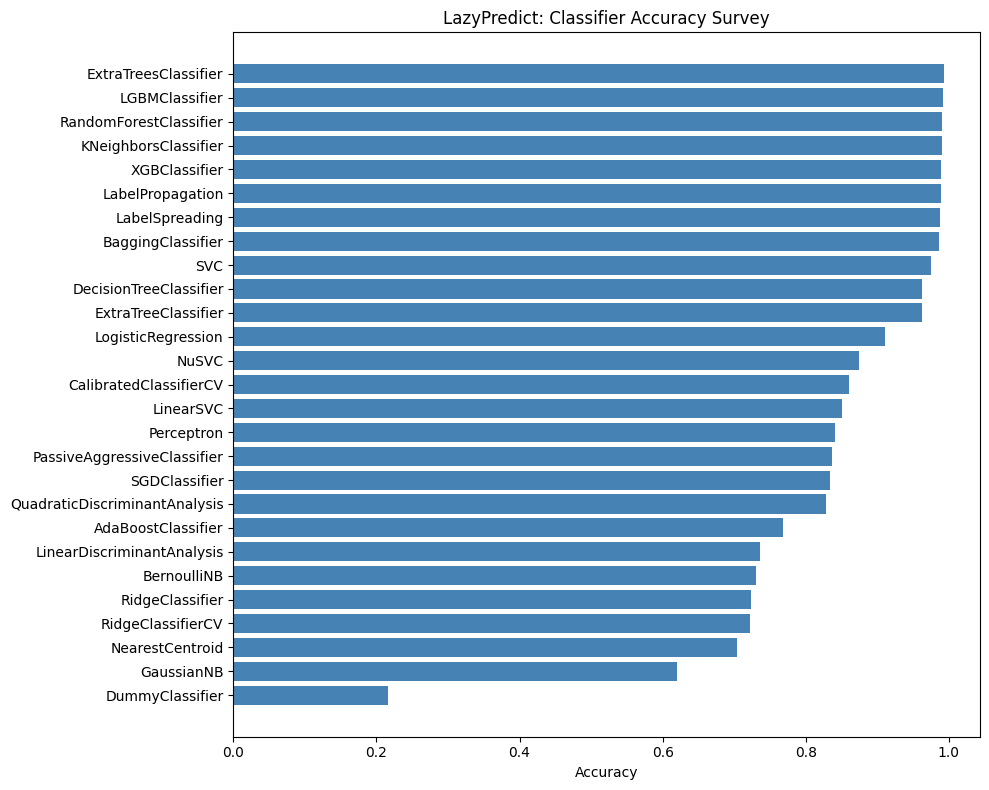

In [15]:
plt.figure(figsize=(10, 8))
models_sorted = models.sort_values('Accuracy', ascending=True)
plt.barh(models_sorted.index, models_sorted['Accuracy'], color='steelblue')
plt.xlabel('Accuracy')
plt.title('LazyPredict: Classifier Accuracy Survey')
plt.tight_layout()
plt.savefig('lazypredict_survey.png', dpi=150)
plt.show()

## Section 6: Model Training & Hyperparameter Tuning

### 6.1 K-Nearest Neighbors (KNN)

In [16]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gs_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn,
                      cv=cv, scoring='f1_weighted', n_jobs=-1, verbose=1)
gs_knn.fit(X_train_pca, y_train)

print('Best params:', gs_knn.best_params_)
print('Best CV F1: ', round(gs_knn.best_score_, 4))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best CV F1:  0.9908


### 6.2 Decision Tree

In [17]:
param_grid_dt = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

gs_dt = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE),
                     param_grid_dt, cv=cv, scoring='f1_weighted',
                     n_jobs=-1, verbose=1)
gs_dt.fit(X_train_pca, y_train)

print('Best params:', gs_dt.best_params_)
print('Best CV F1: ', round(gs_dt.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 2}
Best CV F1:  0.9659


### 6.3 Support Vector Machine (SVM)

In [18]:
param_grid_svm = {
    'C': [1, 10],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

gs_svm = GridSearchCV(SVC(random_state=RANDOM_STATE),
                      param_grid_svm, cv=cv, scoring='f1_weighted',
                      n_jobs=-1, verbose=1)
gs_svm.fit(X_train_pca, y_train)

print('Best params:', gs_svm.best_params_)
print('Best CV F1: ', round(gs_svm.best_score_, 4))

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV F1:  0.9814


### 6.4 Logistic Regression

In [19]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [500]
}

gs_lr = GridSearchCV(LogisticRegression(random_state=RANDOM_STATE),
                     param_grid_lr, cv=cv, scoring='f1_weighted',
                     n_jobs=-1, verbose=1)
gs_lr.fit(X_train_pca, y_train)

print('Best params:', gs_lr.best_params_)
print('Best CV F1: ', round(gs_lr.best_score_, 4))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'C': 10, 'max_iter': 500, 'solver': 'lbfgs'}
Best CV F1:  0.9154


### 6.5 Random Forest (Required)

In [20]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

gs_rf = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE),
                     param_grid_rf, cv=cv, scoring='f1_weighted',
                     n_jobs=-1, verbose=1)
gs_rf.fit(X_train_pca, y_train)

print('Best params:', gs_rf.best_params_)
print('Best CV F1: ', round(gs_rf.best_score_, 4))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}
Best CV F1:  0.9898


### 6.6 XGBoost (Required)

In [21]:
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.05, 0.1, 0.2]
}

gs_xgb = GridSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='mlogloss'),
    param_grid_xgb, cv=cv, scoring='f1_weighted',
    n_jobs=-1, verbose=1
)
gs_xgb.fit(X_train_pca, y_train)

print('Best params:', gs_xgb.best_params_)
print('Best CV F1: ', round(gs_xgb.best_score_, 4))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200}
Best CV F1:  0.9899


## Section 7: Results & Comparison

In [22]:
# Helper function to compute metrics for both train and test sets
def evaluate_model(name, estimator, X_tr, X_te, y_tr, y_te):
    y_pred_train = estimator.predict(X_tr)
    y_pred_test  = estimator.predict(X_te)
    return {
        'Model': name,
        'Train Accuracy':       round(accuracy_score(y_tr, y_pred_train), 4),
        'Test Accuracy':        round(accuracy_score(y_te, y_pred_test),  4),
        'Test F1 (weighted)':   round(f1_score(y_te, y_pred_test, average='weighted'), 4),
        'Test Precision':       round(precision_score(y_te, y_pred_test, average='weighted'), 4),
        'Test Recall':          round(recall_score(y_te, y_pred_test, average='weighted'), 4),
    }

results = [
    evaluate_model('KNN',                 gs_knn.best_estimator_,  X_train_pca, X_test_pca, y_train, y_test),
    evaluate_model('Decision Tree',       gs_dt.best_estimator_,   X_train_pca, X_test_pca, y_train, y_test),
    evaluate_model('SVM',                 gs_svm.best_estimator_,  X_train_pca, X_test_pca, y_train, y_test),
    evaluate_model('Logistic Regression', gs_lr.best_estimator_,   X_train_pca, X_test_pca, y_train, y_test),
    evaluate_model('Random Forest',       gs_rf.best_estimator_,   X_train_pca, X_test_pca, y_train, y_test),
    evaluate_model('XGBoost',             gs_xgb.best_estimator_,  X_train_pca, X_test_pca, y_train, y_test),
]

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())

                     Train Accuracy  Test Accuracy  Test F1 (weighted)  Test Precision  Test Recall
Model                                                                                              
KNN                          1.0000         0.9932              0.9932          0.9932       0.9932
Decision Tree                1.0000         0.9770              0.9770          0.9771       0.9770
SVM                          0.9862         0.9853              0.9853          0.9853       0.9853
Logistic Regression          0.9145         0.9155              0.9151          0.9149       0.9155
Random Forest                1.0000         0.9914              0.9914          0.9914       0.9914
XGBoost                      1.0000         0.9907              0.9907          0.9907       0.9907


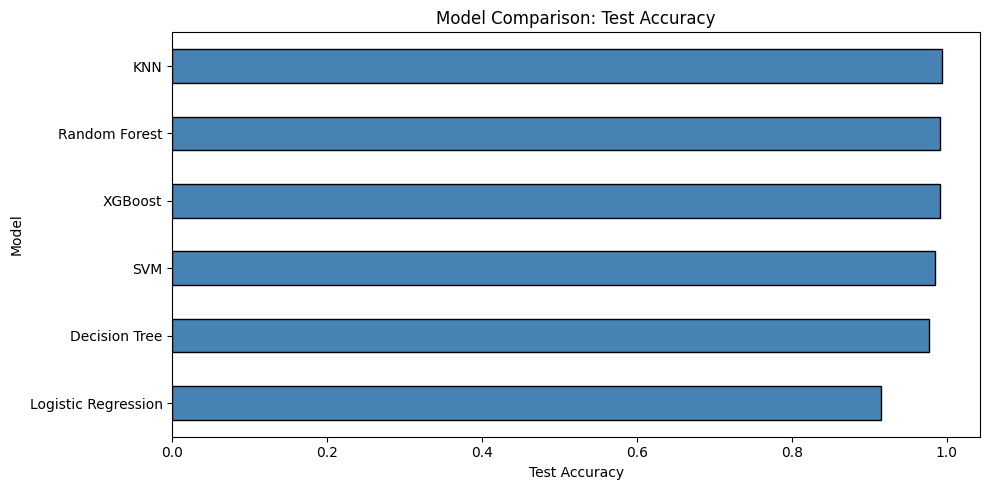

In [23]:
# Bar chart comparing test accuracy across all models
plt.figure(figsize=(10, 5))
results_df['Test Accuracy'].sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Test Accuracy')
plt.title('Model Comparison: Test Accuracy')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

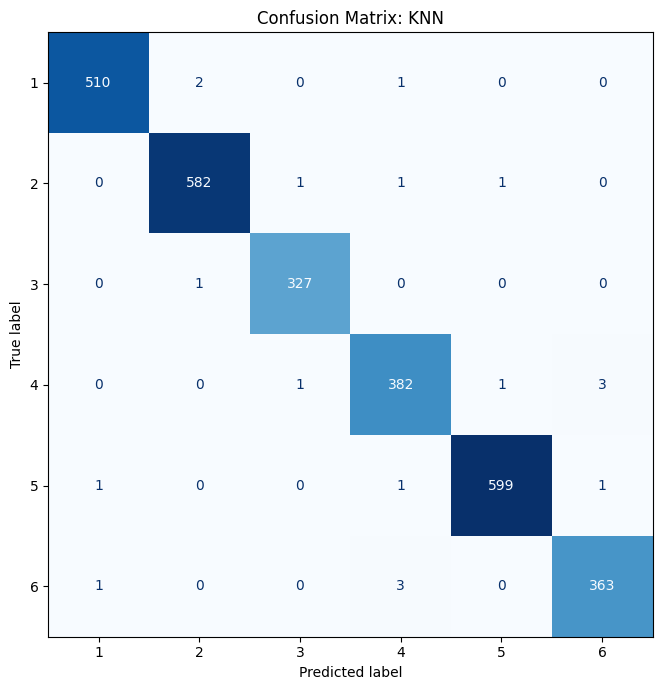

In [24]:
# Confusion matrix for the best performing model (KNN, test accuracy = 0.9932)
best_model = gs_knn.best_estimator_
best_model_name = 'KNN'

y_pred_best = best_model.predict(X_test_pca)
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix: {best_model_name}')
plt.tight_layout()
plt.savefig('confusion_matrix_best.png', dpi=150)
plt.show()

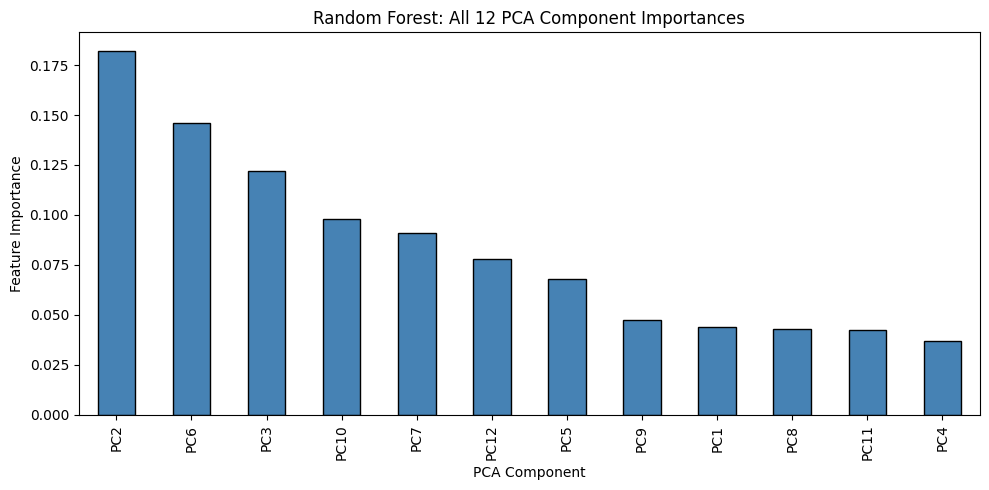

In [27]:
# Feature importances from the Random Forest model
# KNN doesn't have feature importances, so we use RF here for additional insight.
# Components are PCA-transformed so we label them PC1, PC2, etc.
rf_best = gs_rf.best_estimator_
importances = rf_best.feature_importances_
pca_labels = [f'PC{i+1}' for i in range(len(importances))]

imp_series = pd.Series(importances, index=pca_labels).sort_values(ascending=False)[:12]

plt.figure(figsize=(10, 5))
imp_series.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Random Forest: All 12 PCA Component Importances')
plt.ylabel('Feature Importance')
plt.xlabel('PCA Component')
plt.tight_layout()
plt.savefig('feature_importances_rf.png', dpi=150)
plt.show()

In [26]:
# Full classification report for the best model
print(f'Classification Report — {best_model_name}')
print(classification_report(y_test, y_pred_best, target_names=[str(c) for c in le.classes_]))

Classification Report — KNN
              precision    recall  f1-score   support

           1       1.00      0.99      1.00       513
           2       0.99      0.99      0.99       585
           3       0.99      1.00      1.00       328
           4       0.98      0.99      0.99       387
           5       1.00      1.00      1.00       602
           6       0.99      0.99      0.99       367

    accuracy                           0.99      2782
   macro avg       0.99      0.99      0.99      2782
weighted avg       0.99      0.99      0.99      2782



## End of Notebook